# Multivariate Model Progression Table

This notebook builds a model progression table from every file in `/edata/obdw/sandwich_analysis_data` ending with `analysis_wer_coeftest.csv`.

Outputs created by the notebook:
- `multivariate_model_progression_table.csv`: presentation table with one row per variable
- `multivariate_model_progression_table_full.csv`: same table including `(Intercept)` and `pid`
- `multivariate_model_progression_counts_detail.csv`: model-specific count details
- `multivariate_model_progression_long_detail.csv`: long-form coefficient detail

Count handling:
- The main `Count` column is the maximum available count observed for that variable across the included models.
- Model-specific counts are also saved separately so you can inspect differences across models.

In [6]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

sys.path.insert(0, '/home/NETID/emd5')
from avh_utils import decode_variable_name

DATA_DIR = Path('/edata/obdw/sandwich_analysis_data')
MODEL_FILES = sorted(DATA_DIR.glob('*analysis_wer_coeftest.csv'))
# ToDo: remove this once the location_stratified_effect_coding_analysis_wer_coeftest.csv file is updated with the correct data
MODEL_FILES = [f for f in MODEL_FILES if f.name != 'location_stratified_effect_coding_analysis_wer_coeftest.csv']

if not MODEL_FILES:
    raise FileNotFoundError('No files ending with analysis_wer_coeftest.csv were found in /edata/obdw/sandwich_analysis_data')

print('Models included:')
for model_file in MODEL_FILES:
    print(f'  - {model_file.name}')

Models included:
  - basic_analysis_wer_coeftest.csv
  - basic_plus_analysis_wer_coeftest.csv
  - basic_plus_clinical_analysis_wer_coeftest.csv
  - basic_plus_clinical_sdh_analysis_wer_coeftest.csv
  - location_encoded_analysis_wer_coeftest.csv
  - location_stratified_analysis_wer_coeftest.csv


In [7]:
def standardize_coeftest_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        'Std. Error': 'Std_Error',
        'Std..Error': 'Std_Error',
        'Pr(>|t|)': 'p_value',
        'p.value': 'p_value',
        't value': 't_value',
        't.value': 't_value',
    }
    out = df.rename(columns={old: new for old, new in rename_map.items() if old in df.columns}).copy()
    if 'Variable' not in out.columns:
        out['Variable'] = out.index.astype(str)
    return out


def significance_stars(p_value):
    if pd.isna(p_value):
        return ''
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return ''


def format_model_cell(estimate, p_value):
    if pd.isna(estimate):
        return '—'
    return f'{estimate:.3f}{significance_stars(p_value)}'


def parse_numeric_token(token):
    try:
        return float(token)
    except (TypeError, ValueError):
        return None


def compute_variable_count(term: str, analysis_df):
    if analysis_df is None:
        return pd.NA

    term = str(term).strip().strip('\"')
    if term in {'(Intercept)', 'pid'}:
        return pd.NA

    if term in analysis_df.columns:
        series = analysis_df[term]
        values = set(series.dropna().unique().tolist())
        if values and values.issubset({0, 1, 0.0, 1.0, True, False}):
            return int((series == 1).sum())
        return int(series.notna().sum())

    parts = term.split('_')
    if len(parts) >= 2:
        base_name = '_'.join(parts[:-1])
        category_value = parse_numeric_token(parts[-1])
        if category_value is not None and base_name in analysis_df.columns:
            numeric_series = pd.to_numeric(analysis_df[base_name], errors='coerce')
            return int((numeric_series == category_value).sum())

    return pd.NA


def build_progression_outputs(model_files, univariate_path=None):
    records = []

    for model_path in model_files:
        coeftest_df = pd.read_csv(model_path, index_col=0)
        coeftest_df = standardize_coeftest_columns(coeftest_df)

        analysis_data_path = DATA_DIR / model_path.name.replace('_wer_coeftest.csv', '.csv')
        analysis_df = pd.read_csv(analysis_data_path, index_col=0) if analysis_data_path.exists() else None

        for _, row in coeftest_df.iterrows():
            variable_raw = str(row['Variable'])
            records.append({
                'Variable_Raw': variable_raw,
                'Variable': decode_variable_name(variable_raw),
                'Model': model_path.name,
                'Estimate': row.get('Estimate', pd.NA),
                'p_value': row.get('p_value', pd.NA),
                'Formatted': format_model_cell(row.get('Estimate', pd.NA), row.get('p_value', pd.NA)),
                'Count_ModelSpecific': compute_variable_count(variable_raw, analysis_df),
                'Source_Data_File': analysis_data_path.name if analysis_data_path.exists() else pd.NA,
            })

    long_detail = pd.DataFrame(records)

    count_detail = (
        long_detail
        .pivot(index=['Variable_Raw', 'Variable'], columns='Model', values='Count_ModelSpecific')
        .reset_index()
    )

    model_columns = [model_path.name for model_path in model_files]
    count_detail.columns.name = None

    def summarize_counts(row):
        values = [row[col] for col in model_columns if col in row.index and pd.notna(row[col])]
        if not values:
            return pd.Series({'Count': pd.NA, 'Count_Min': pd.NA, 'Count_Max': pd.NA, 'Models_With_Count': 0})
        values = [int(v) for v in values]
        return pd.Series({
            'Count': max(values),
            'Count_Min': min(values),
            'Count_Max': max(values),
            'Models_With_Count': len(values),
        })

    count_summary = count_detail.apply(summarize_counts, axis=1)
    count_detail = pd.concat([count_detail, count_summary], axis=1)

    progression_matrix = (
        long_detail
        .pivot(index='Variable_Raw', columns='Model', values='Formatted')
        .reindex(columns=model_columns)
    )

    variable_lookup = long_detail[['Variable_Raw', 'Variable']].drop_duplicates().set_index('Variable_Raw')
    count_lookup = count_detail.set_index('Variable_Raw')[['Count', 'Count_Min', 'Count_Max', 'Models_With_Count']]

    progression_table_full = variable_lookup.join(count_lookup).join(progression_matrix)
    progression_table_full = progression_table_full.reset_index()

    # ── Merge univariate regression results ───────────────────────────────────
    if univariate_path is not None and Path(univariate_path).exists():
        uni_df = pd.read_csv(univariate_path)
        uni_df['Univariate_WER'] = uni_df.apply(
            lambda r: format_model_cell(r['Coefficient'], r['p-value']), axis=1
        )
        uni_lookup = uni_df.set_index('Variable')['Univariate_WER']
        progression_table_full['Univariate_WER'] = (
            progression_table_full['Variable_Raw'].map(uni_lookup).fillna('—')
        )
        col_order = (['Count', 'Variable', 'Variable_Raw', 'Univariate_WER']
                     + model_columns
                     + ['Count_Min', 'Count_Max', 'Models_With_Count'])
    else:
        col_order = (['Count', 'Variable', 'Variable_Raw']
                     + model_columns
                     + ['Count_Min', 'Count_Max', 'Models_With_Count'])

    progression_table_full = progression_table_full[
        [c for c in col_order if c in progression_table_full.columns]
    ]
    progression_table_full[model_columns] = progression_table_full[model_columns].fillna('—')
    if 'Univariate_WER' in progression_table_full.columns:
        progression_table_full['Univariate_WER'] = progression_table_full['Univariate_WER'].fillna('—')
    progression_table_full = progression_table_full.sort_values(
        ['Count', 'Variable', 'Variable_Raw'], ascending=[False, True, True], na_position='last'
    ).reset_index(drop=True)

    progression_table = progression_table_full[
        ~progression_table_full['Variable_Raw'].isin(['(Intercept)', 'pid'])
    ].reset_index(drop=True)

    return progression_table, progression_table_full, count_detail, long_detail


In [8]:
UNIVARIATE_PATH = Path('/home/NETID/emd5/Univariate_Regression_from_X_basic_plus_clin_sdh_location_encoded.csv')

progression_table, progression_table_full, count_detail, long_detail = build_progression_outputs(
    MODEL_FILES, univariate_path=UNIVARIATE_PATH
)

presentation_output = DATA_DIR / 'multivariate_model_progression_table.csv'
full_output = DATA_DIR / 'multivariate_model_progression_table_full.csv'
counts_output = DATA_DIR / 'multivariate_model_progression_counts_detail.csv'
long_output = DATA_DIR / 'multivariate_model_progression_long_detail.csv'

progression_table.to_csv(presentation_output, index=False)
progression_table_full.to_csv(full_output, index=False)
count_detail.to_csv(counts_output, index=False)
long_detail.to_csv(long_output, index=False)

print(f'Saved presentation table to: {presentation_output}')
print(f'Saved full table to: {full_output}')
print(f'Saved count detail to: {counts_output}')
print(f'Saved long detail to: {long_output}')
print()
print(f'Presentation table shape: {progression_table.shape}')
print(f'Full table shape: {progression_table_full.shape}')

display(progression_table)


Saved presentation table to: /edata/obdw/sandwich_analysis_data/multivariate_model_progression_table.csv
Saved full table to: /edata/obdw/sandwich_analysis_data/multivariate_model_progression_table_full.csv
Saved count detail to: /edata/obdw/sandwich_analysis_data/multivariate_model_progression_counts_detail.csv
Saved long detail to: /edata/obdw/sandwich_analysis_data/multivariate_model_progression_long_detail.csv

Presentation table shape: (79, 13)
Full table shape: (81, 13)


,Count,Variable,Variable_Raw,Univariate_WER,basic_analysis_wer_coeftest.csv,basic_plus_analysis_wer_coeftest.csv,basic_plus_clinical_analysis_wer_coeftest.csv,basic_plus_clinical_sdh_analysis_wer_coeftest.csv,location_encoded_analysis_wer_coeftest.csv,location_stratified_analysis_wer_coeftest.csv,Count_Min,Count_Max,Models_With_Count
0,2859,AMOS,AMOS,-0.238***,-0.187***,-0.181***,-0.196***,-0.182***,-0.144***,-0.126***,2859,2859,4
1,2859,Pause Proportion,pause_proportion,0.556,—,0.119,0.166,0.056,0.125,0.353,2859,2859,3
2,2686,Serious Mental Illness (SMI) Diagnosis,dx_group_smi,-0.063,—,—,0.091,0.064,0.080,0.115,2686,2686,2
3,2664,SCL-9 Moderate Distress (≥1.0),SCL9_moderate,0.146,—,—,-0.124,-0.226,-0.211,—,2664,2664,2
4,2410,PHQ-9 Total High,PHQ9_high,-0.097,—,—,-0.085,-0.153,-0.039,-0.086,2410,2410,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,<NA>,sds.2.social.leisure.disruption,sds.2.social.leisure.disruption,—,—,—,-0.000,-0.001,0.000,—,<NA>,<NA>,0
75,<NA>,sds.3.home.family.disruption,sds.3.home.family.disruption,—,—,—,-0.000,-0.000,-0.001*,—,<NA>,<NA>,0
76,<NA>,sds.4.school.work.missed,sds.4.school.work.missed,—,—,—,0.000,0.000,0.000,—,<NA>,<NA>,0
77,<NA>,sds.5.less.productive.days,sds.5.less.productive.days,—,—,—,-0.001*,-0.000,0.000,—,<NA>,<NA>,0


## Visualization

This visualization uses the presentation table by default because it is easier to read than the full table.

What the figure shows:
- Rows are variables
- Columns are model files
- Cell color shows the coefficient estimate
- Cell text shows the formatted coefficient with significance stars
- Blank cells mean the variable was not included in that model

Set `use_full_table = True` in the next cell if you want to visualize the full table instead.

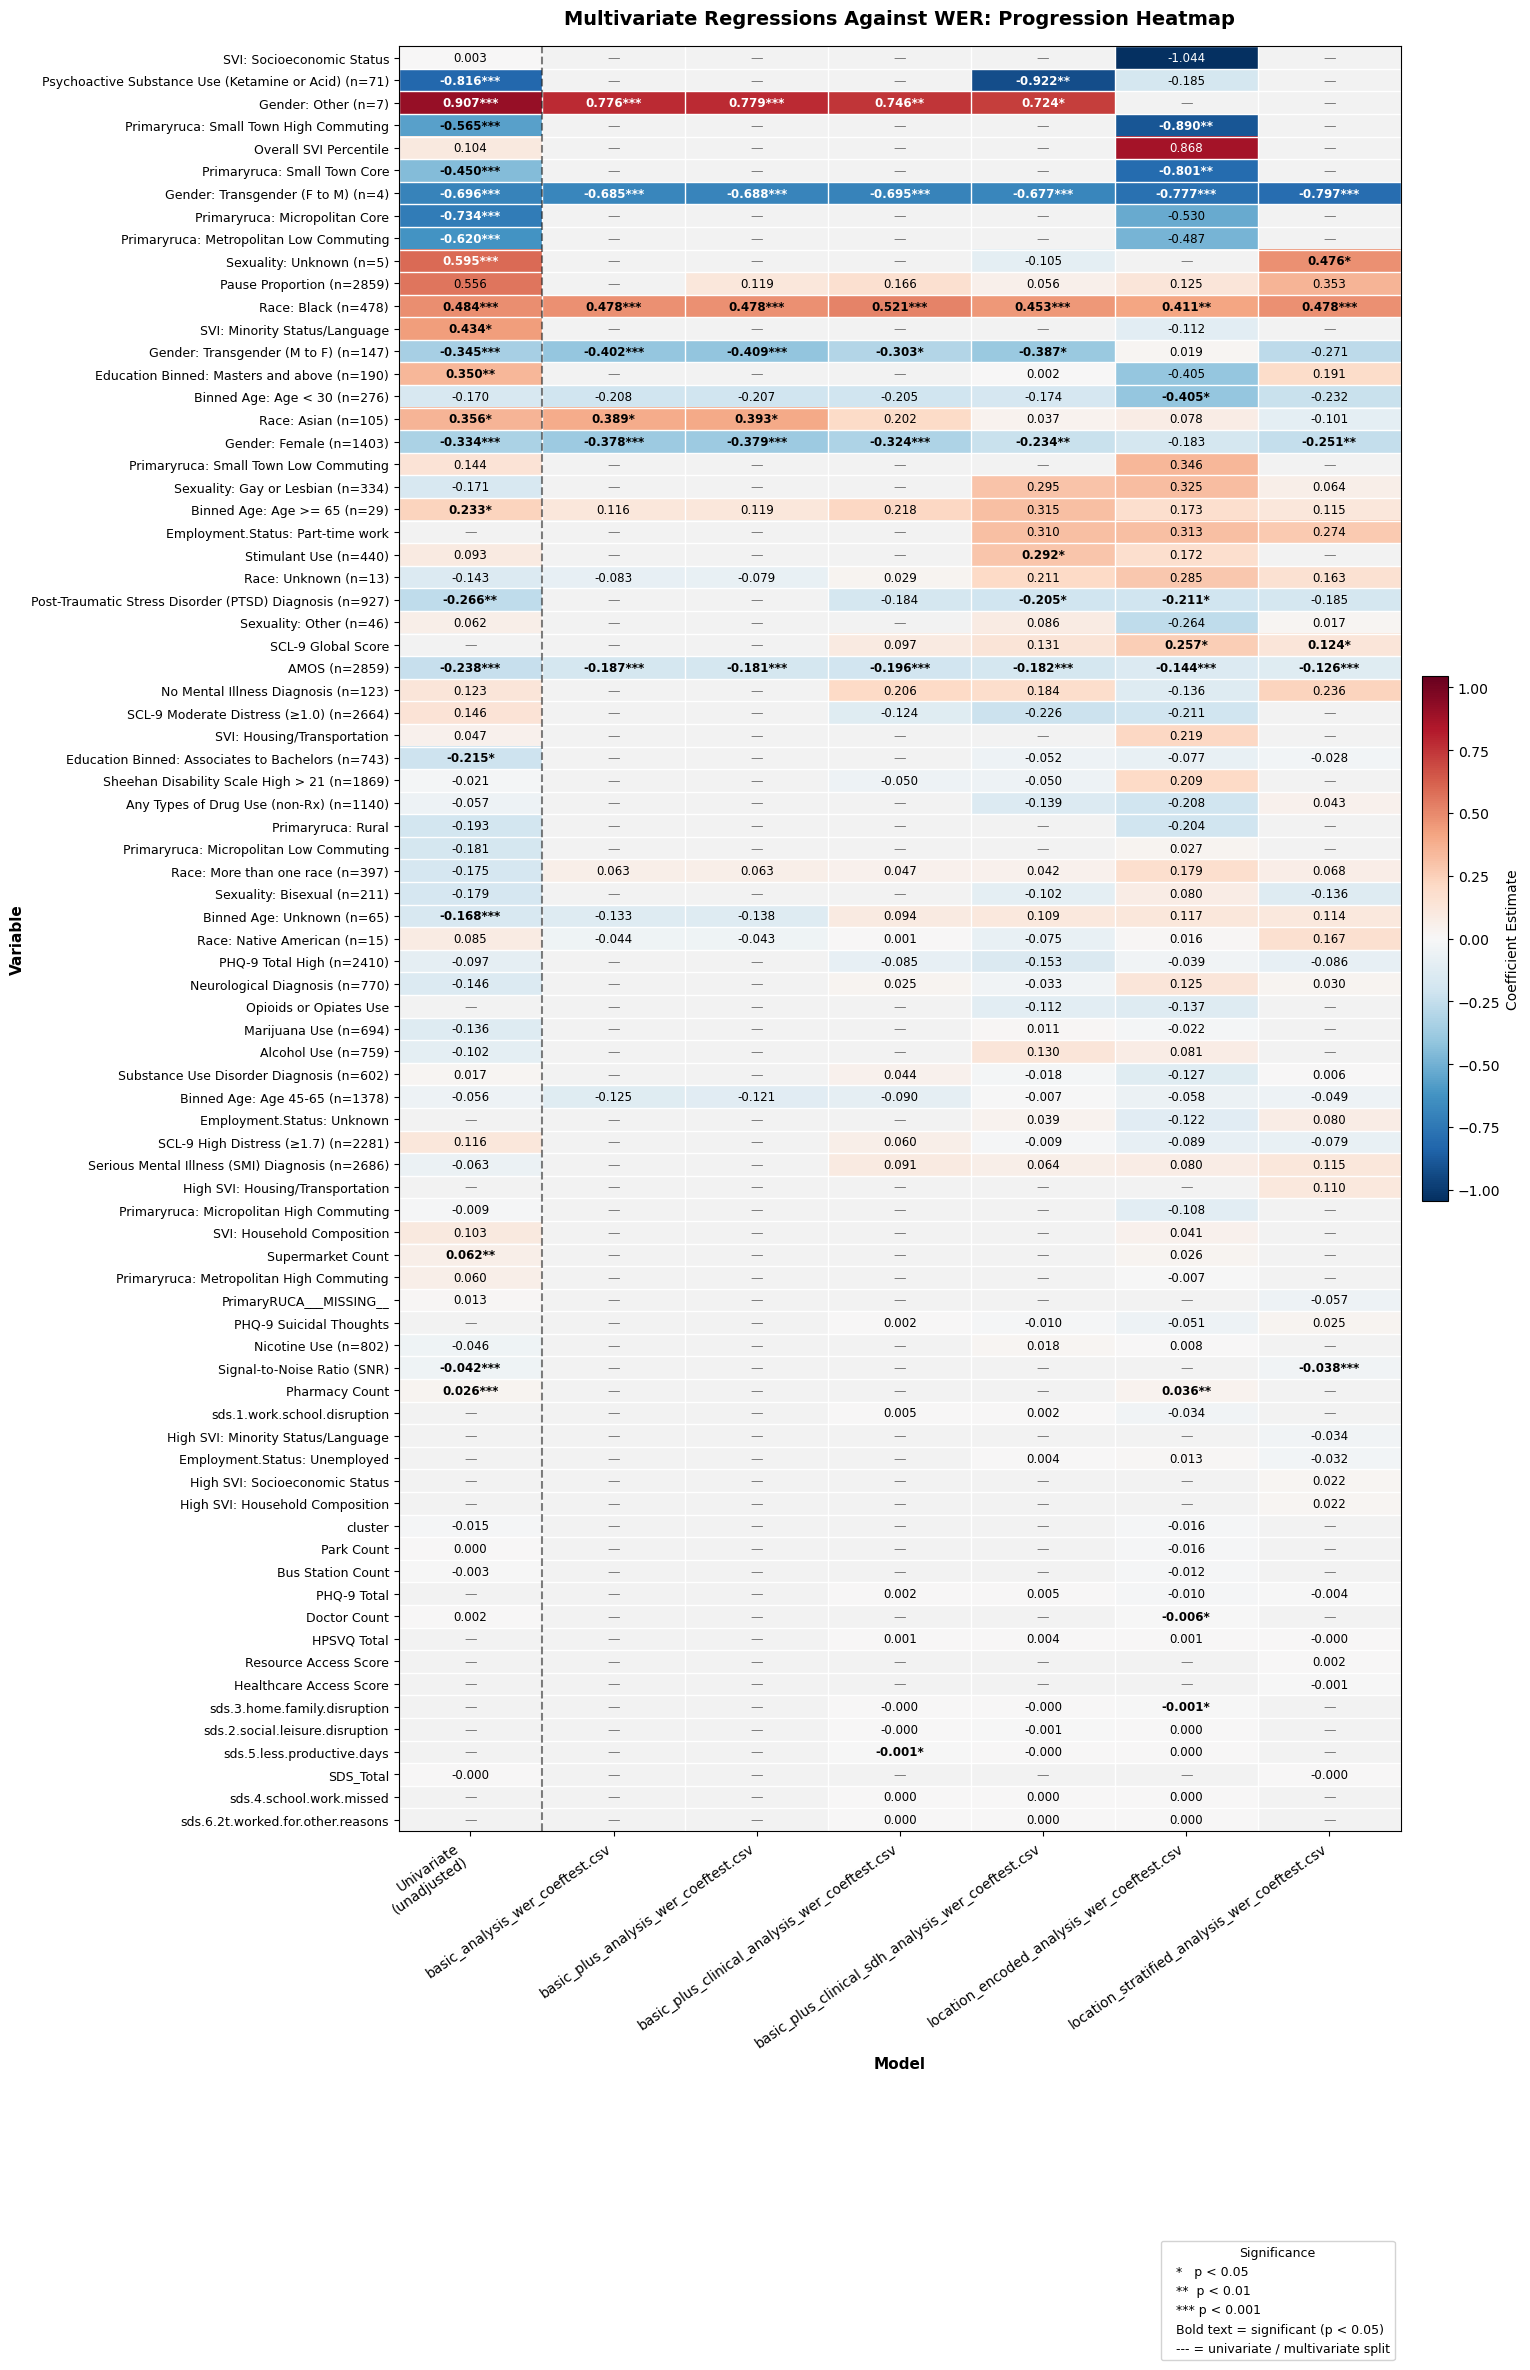

Saved visualization to: /edata/obdw/sandwich_analysis_data/multivariate_model_progression_heatmap.png


In [9]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

use_full_table = False
table_path = full_output if use_full_table else presentation_output
plot_title = (
    'Multivariate Regressions Against WER: Progression Heatmap (Full Table)'
    if use_full_table else
    'Multivariate Regressions Against WER: Progression Heatmap'
)
plot_output = DATA_DIR / ('multivariate_model_progression_heatmap_full.png' if use_full_table else 'multivariate_model_progression_heatmap.png')

plot_df = pd.read_csv(table_path)

# Build ordered column list: Univariate_WER first, then multivariate model files
univariate_col = 'Univariate_WER'
multivariate_columns = [model_file.name for model_file in MODEL_FILES]
all_display_columns = (
    ([univariate_col] if univariate_col in plot_df.columns else [])
    + [col for col in multivariate_columns if col in plot_df.columns]
)

if not all_display_columns:
    raise ValueError('No model columns were found in the selected progression table.')

def parse_estimate(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text in {'', '—'}:
        return np.nan
    match = re.match(r'^([-+]?[0-9]*\.?[0-9]+)', text)
    return float(match.group(1)) if match else np.nan

def is_significant(label):
    """Return True if the formatted cell label ends with one or more significance stars."""
    return str(label).strip().endswith('*')

heatmap_values = plot_df[all_display_columns].apply(lambda column: column.map(parse_estimate))
annotation_values = plot_df[all_display_columns].fillna('—').astype(str)

if 'Count' in plot_df.columns:
    row_labels = [f"{variable} (n={int(count)})" if pd.notna(count) else str(variable) for variable, count in zip(plot_df['Variable'], plot_df['Count'])]
else:
    row_labels = plot_df['Variable'].astype(str).tolist()

valid_rows = heatmap_values.notna().any(axis=1)
heatmap_values = heatmap_values.loc[valid_rows].reset_index(drop=True)
annotation_values = annotation_values.loc[valid_rows].reset_index(drop=True)
row_labels = [label for label, keep in zip(row_labels, valid_rows) if keep]

sort_key = heatmap_values.abs().max(axis=1).fillna(-np.inf)
sort_order = sort_key.sort_values(ascending=False).index
heatmap_values = heatmap_values.loc[sort_order].reset_index(drop=True)
annotation_values = annotation_values.loc[sort_order].reset_index(drop=True)
row_labels = [row_labels[idx] for idx in sort_order]

fig_height = max(8, min(24, 0.42 * len(row_labels)))
fig_width = max(12, 2.2 * len(all_display_columns))
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

masked_values = np.ma.masked_invalid(heatmap_values.to_numpy(dtype=float))
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color='#f2f2f2')

max_abs = np.nanmax(np.abs(masked_values)) if masked_values.count() > 0 else 1.0
if not np.isfinite(max_abs) or max_abs == 0:
    max_abs = 1.0

image = ax.imshow(masked_values, aspect='auto', cmap=cmap, vmin=-max_abs, vmax=max_abs)

# X-axis labels: distinguish the univariate column visually
x_labels = [
    'Univariate\n(unadjusted)' if col == univariate_col else col
    for col in all_display_columns
]
ax.set_xticks(np.arange(len(all_display_columns)))
ax.set_xticklabels(x_labels, rotation=35, ha='right', fontsize=10)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title(plot_title, fontsize=14, fontweight='bold', pad=16)

# Dashed separator line between univariate and first multivariate column
if univariate_col in plot_df.columns and len(multivariate_columns) > 0:
    ax.axvline(x=0.5, color='black', linewidth=1.5, linestyle='--', alpha=0.5)

for row_idx in range(len(row_labels)):
    for col_idx in range(len(all_display_columns)):
        label = annotation_values.iloc[row_idx, col_idx]
        numeric_value = heatmap_values.iloc[row_idx, col_idx]
        if pd.isna(numeric_value):
            ax.text(col_idx, row_idx, '—', ha='center', va='center', fontsize=9, color='#7a7a7a')
        else:
            text_color = 'white' if abs(numeric_value) > 0.55 * max_abs else 'black'
            weight = 'bold' if is_significant(label) else 'normal'
            ax.text(col_idx, row_idx, label, ha='center', va='center', fontsize=8.5,
                    color=text_color, fontweight=weight)

colorbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label('Coefficient Estimate', rotation=90)

ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('Variable', fontsize=11, fontweight='bold')
ax.set_xticks(np.arange(-0.5, len(all_display_columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)

# Significance legend
legend_handles = [
    mpatches.Patch(color='none', label='*   p < 0.05'),
    mpatches.Patch(color='none', label='**  p < 0.01'),
    mpatches.Patch(color='none', label='*** p < 0.001'),
    mpatches.Patch(color='none', label='Bold text = significant (p < 0.05)'),
    mpatches.Patch(color='none', label='--- = univariate / multivariate split'),
]
ax.legend(
    handles=legend_handles,
    loc='lower right',
    bbox_to_anchor=(1.0, -0.30),
    fontsize=9,
    title='Significance',
    title_fontsize=9,
    frameon=True,
    framealpha=0.85,
    handlelength=0,
)

plt.tight_layout()
plt.savefig(plot_output, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved visualization to: {plot_output}')


## Encoding Choices: One-Hot vs Effect Coding (and What R Does)

### 1. One-hot (dummy) encoding in regression

For a categorical predictor with $K$ levels, one-hot encoding creates indicator variables.
To avoid perfect multicollinearity with an intercept, you keep $K-1$ indicators and drop one level (the reference).

For example, with levels $A,B,C$ and reference $A$:

$$
Y = \beta_0 + \beta_B \cdot I(B) + \beta_C \cdot I(C) + \epsilon
$$

Interpretation:
- $\beta_0 = \mathbb{E}[Y \mid A]$ (mean for reference level)
- $\beta_B = \mathbb{E}[Y \mid B] - \mathbb{E}[Y \mid A]$
- $\beta_C = \mathbb{E}[Y \mid C] - \mathbb{E}[Y \mid A]$

So dummy coding compares each non-reference category to the chosen reference category.

### 2. Is dropping the largest category a correct choice?

Yes, it is statistically valid. Any category can be the reference and the model fit/predictions are unchanged; only coefficient interpretation changes.

Dropping the largest category is often practical because:
- coefficients are contrasts against the most common group,
- standard errors for those contrasts are often more stable,
- interpretation can be more clinically intuitive if that group is a natural baseline.

But it is not mathematically required. It is an interpretation choice.

### 3. Does R automatically choose a reference category?

Yes. In standard formula regression in R (for factors), R uses treatment contrasts by default and drops one level automatically.
The default reference is typically the first factor level (often alphabetical unless you explicitly reorder with factor levels or relevel).

So if you pass a factor to R, you do not manually one-hot encode it first.
R handles the $K-1$ coding internally.

### 4. Should you remove one-hot encoding and let R do it?

Conceptually, both approaches are equivalent if done correctly:
- pre-encode in Python and send numeric columns, or
- send categorical/factor variables and let R encode.

Reasons to keep your current explicit encoding pipeline:
- full control over the reference category (for reproducibility),
- consistent behavior across Python and R outputs,
- easier auditing when many transformed features are already in your pipeline.

So your position (do not remove one-hot encoding) is reasonable.

### 5. Effect coding: what changes mathematically?

Effect coding (sum-to-zero coding) changes the interpretation from "vs a reference" to "vs the grand mean".

With three levels $A,B,C$, effect coding can be represented by two coded columns with constraints so level effects sum to zero.
A common parameterization implies:

$$
\alpha_A + \alpha_B + \alpha_C = 0
$$

and model:

$$
Y = \mu + \alpha_g + \epsilon
$$

where $\mu$ is the grand mean across groups (balanced sense under coding), and each $\alpha_g$ is deviation of group $g$ from that mean.

Interpretation difference:
- Dummy coding: category effects are differences from one chosen reference.
- Effect coding: category effects are differences from the overall mean.

### 6. Dummy coding vs effect coding in practice

- Fit quality and predictions are unchanged (same model space).
- Hypothesis tests for overall factor effects are unchanged.
- Individual coefficient values and meanings differ because parameterization differs.

Choose dummy coding when baseline comparisons are the scientific question.
Choose effect coding when "above/below overall average" is the scientific question.

### 7. Recommendation for this project

Given your workflow and request:
- keep one-hot/dummy coding,
- keep explicit reference selection (largest category is acceptable and often useful),
- optionally run a sensitivity analysis with effect coding for interpretability checks,
- report clearly which coding scheme was used for each table/figure.
